# Thirstwave detection

## What is a thirstwave?

> Thirstwave is a new term (2025) defined by Kukal and Hobbins to describe **three or more consecutive days of extreme evaporative demand**.

Evaporative demand is considered "extreme" if the daily ETos value is greater than the 90th percentile corresponding to each Julian day.

The 90th percentile is defined using a 15-day moving window centered on the Julian day being evaluated over the baseline period, 1981-2000.

For example, to find the 90th percentile for April 15th we:
1. Gather ETos data for April 1st - April 30th for 1981 to 2000. We'll have $30 \times 20 = 600$ daily observations.
2. Find the 90th percentile of this distribution. This is the threshold and any value on April 15th larger than this is considered "extreme".

## What this notebook does

1. Computes the 90th percetiles of ETos for all experiment $\times$ model combinations
2. Saves them as `.nc` files under `📂-- thirstwave_detection/90th_percentiles`

In [6]:
from dask.distributed import Client, LocalCluster

cluster = LocalCluster()
client = cluster.get_client() # connect client to our local cluster
client

/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41445 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:41445/status,
Dashboard: http://127.0.0.1:41445/status,Workers: 16
Total threads: 256,Total memory: 503.39 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34207,Workers: 0
Dashboard: http://127.0.0.1:41445/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40237,Total threads: 16
Dashboard: http://127.0.0.1:39159/status,Memory: 31.46 GiB
Nanny: tcp://127.0.0.1:41391,


In [7]:
import xarray as xr
from pathlib import Path

# Load test data
model = "MIROC6"
experiment = "historical"
basedir = "/work10/archive/CMIP6/CMIP-SSPs/outputs"
path = Path(basedir) / model / experiment / f"{model}_{experiment}_daily_ET0_18500101-20141231.nc"
da = xr.open_dataset(path, chunks="auto").ET0
da

<xarray.DataArray 'ET0' (time: 60265, lat: 128, lon: 256)> Size: 16GB
dask.array<open_dataset-ET0, shape=(60265, 128, 256), dtype=float64, chunksize=(12407, 26, 52), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 482kB 1850-01-01T12:00:00 ... 2014-12-31T1...
  * lat      (lat) float64 1kB -88.93 -87.54 -86.14 -84.74 ... 86.14 87.54 88.93
  * lon      (lon) float64 2kB 0.0 1.406 2.812 4.219 ... 354.4 355.8 357.2 358.6
    height   float64 8B ...
Attributes:
    units:      mm day-1
    long_name:  FAO-56 Penman-Monteith reference evapotranspiration

In [8]:
# Remove all February 29ths
da_noleap = da.convert_calendar("noleap")

# Add 'dayofyear' coordinate (1 = Jan. 1st, ... , 365 = Dec. 31st)
doy = da_noleap.time.dt.dayofyear
da_noleap = da_noleap.assign_coords(dayofyear=doy)
da_noleap

<xarray.DataArray 'ET0' (time: 60225, lat: 128, lon: 256)> Size: 16GB
dask.array<getitem, shape=(60225, 128, 256), dtype=float64, chunksize=(12053, 26, 52), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 482kB 1850-01-01 12:00:00 ... 2014-12-31 12:00:00
    dayofyear  (time) int64 482kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365
  * lat        (lat) float64 1kB -88.93 -87.54 -86.14 ... 86.14 87.54 88.93
  * lon        (lon) float64 2kB 0.0 1.406 2.812 4.219 ... 355.8 357.2 358.6
    height     float64 8B ...
Attributes:
    units:      mm day-1
    long_name:  FAO-56 Penman-Monteith reference evapotranspiration

In [ ]:
# Select data from grid cell 0 only
etos_cell = da_noleap.sel(lat=0, lon=0, method="nearest")

# Reference period only (1981-2000)
climo = etos_cell.sel(time=slice('1981', '2000'))

climo

<xarray.DataArray 'ET0' (time: 7300)> Size: 58kB
dask.array<getitem, shape=(7300,), dtype=float64, chunksize=(6903,), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 58kB 1981-01-01 12:00:00 ... 2000-12-31 12:00:00
    dayofyear  (time) int64 58kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
    lat        float64 8B 0.7004
    lon        float64 8B 0.0
    height     float64 8B ...
Attributes:
    units:      mm day-1
    long_name:  FAO-56 Penman-Monteith reference evapotranspiration

In [10]:
def get_90th_percentiles(climo: xr.DataArray):
    """
    **climo** is a DataArray containing the values of ET0 over the baseline period (1981-2000).
        It should have a 'dayofyear' coordinate [1, 2, 3, ... , 365]

    Computes the 90th percentile of ET0 for each Julian day. The 90th percentile is defined using
    a 15-day moving window centered on the Julian day being evaluated over the baseline period (1981-2000).
    
    For example, to find the 90th percentile for April 15th we:
    1. Gather ETos data for April 1st - April 30th for 1981 to 2000. We'll have $30 \times 20 = 600$ daily observations.
    2. Find the 90th percentile of these values. Any value of ET0 on April 15th larger than this is considered "extreme".
    """
    percentiles = (climo.pad(time=(7,7), mode='wrap')  # Wrap the time series with a 7-day buffer at both ends (Cyclic Padding)
            .rolling(time=15, center=True) 
            .construct('window_dim')
            .isel(time=slice(7, -7))                   # Ensure the 'time' dimension returns to its original length
            .groupby('dayofyear')                      # Group by our custom coord, not time.dayofyear
            .quantile(0.9, dim=['time', 'window_dim']))
    
    return percentiles

test_percentiles = get_90th_percentiles(climo=climo)
vals = test_percentiles.values
vals

array([5.94010123, 5.94010123, 5.9445767 , 5.94774362, 5.96712765,
       5.96908769, 5.96715124, 5.96908769, 5.97469629, 6.00660874,
       6.00827839, 6.00736951, 6.01653863, 6.02708208, 6.03375415,
       6.0484207 , 6.05764868, 6.09567301, 6.0991639 , 6.11690205,
       6.15296179, 6.16756767, 6.15739474, 6.17957981, 6.18956606,
       6.20610893, 6.23101806, 6.24373038, 6.30020071, 6.32165594,
       6.35532258, 6.36419805, 6.37306148, 6.39199086, 6.39955855,
       6.39603569, 6.41344109, 6.43473936, 6.43473936, 6.43004547,
       6.43951768, 6.45252137, 6.45252137, 6.46817793, 6.51990337,
       6.54455575, 6.57010521, 6.56654565, 6.57010521, 6.59180556,
       6.61698436, 6.59180556, 6.58590445, 6.61698436, 6.59558868,
       6.61405144, 6.59180556, 6.59516097, 6.60993382, 6.63522216,
       6.63572249, 6.66181926, 6.67113692, 6.66666005, 6.63572249,
       6.61452096, 6.62353764, 6.62579555, 6.61067159, 6.6212874 ,
       6.61067159, 6.57820411, 6.62267654, 6.5619811 , 6.52361

/tmp/ipykernel_3862185/1500167577.py:5: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(x=doy, y=vals, fmt="r-")
/tmp/ipykernel_3862185/1500167577.py:6: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(x=doy, y=jan98.values, color='black')


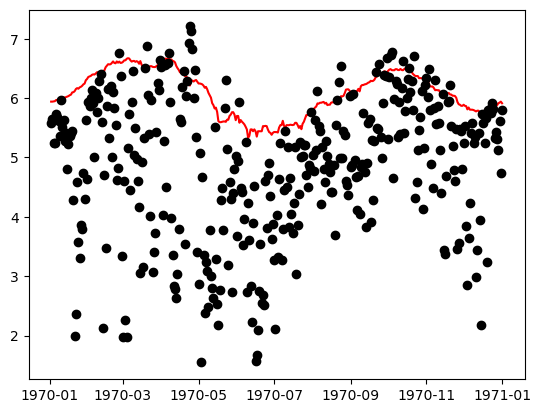

In [29]:
import matplotlib.pyplot as plt
import numpy as np
jan98 = climo.sel(time='1998')
doy = np.arange(1, 366)
plt.plot_date(x=doy, y=vals, fmt="r-")
plt.plot_date(x=doy, y=jan98.values, color='black')
